### Load dataset and construct the L-ensemble

In [9]:
import datetime

import pandas as pd
import numpy as np

from utils import get_age_in_days, construct_L_Ensemble

df = pd.read_csv('tournesol_scores_above_20_2024-03-27.csv')

#Test parameters
bundle_size = 4
alpha = 0.1
##Model parameters
power = 2.8 
discount = 7.3
caracteristic_time = 31

recent_videos_proportion = 0.75
recent_videos_to_sample = int(bundle_size * recent_videos_proportion)
old_videos_to_sample = int(bundle_size * (1 - recent_videos_proportion))
                           
#Computes the age of each video
today = datetime.datetime(2024, 3, 28) #one day older than dataset
df['age_in_days'] = df.apply(lambda x: get_age_in_days(x, today), axis="columns")

dpp = construct_L_Ensemble(df, power, discount, caracteristic_time)

L_dual = Phi Phi.T was computed: Phi (dxN) with d<N


### Measures the number of different channels per bundle

<AxesSubplot:ylabel='Count'>

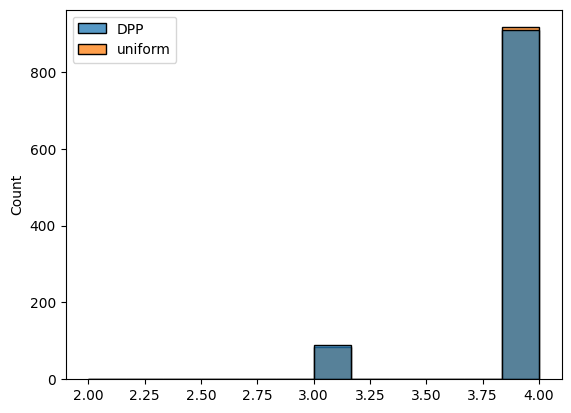

In [12]:
import seaborn as sns

n_tests = 1000

n_channel = pd.DataFrame(columns = ['DPP', 'uniform'])

#dpp sampling
n_channel['DPP'] = pd.Series(
    [len(df.loc[
        df.index[dpp.sample_exact_k_dpp(size=bundle_size)],
        'channel'
        ].unique()
    ) 
    for i in range(n_tests)],
    name="DPP"
)

# Uniform sampling
n_channel['uniform'] = pd.Series(
    data=[len(
        pd.concat([
            df.loc[df["age_in_days"] <= 21]
                .sample(
                    n=recent_videos_to_sample, 
                    replace=False
            ), 
            df.loc[df["age_in_days"] > 21]
                .sample(
                    n=old_videos_to_sample, 
                    replace=False
            )
        ])['channel']
            .unique()
    )
    for i in range(n_tests)
    ],
    name="uniform"
)
   
sns.histplot(n_channel)

### View count, age and duration distributions

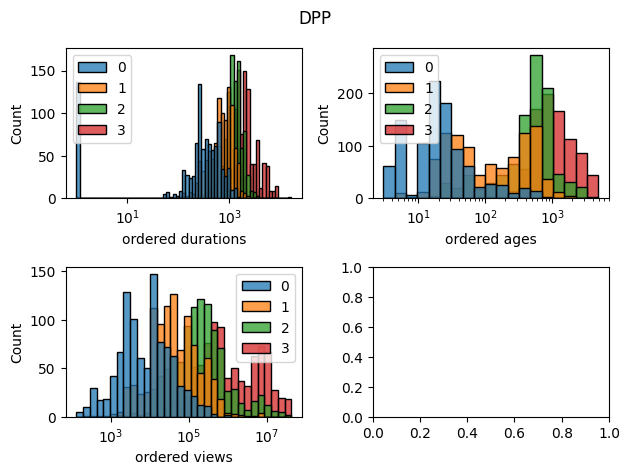

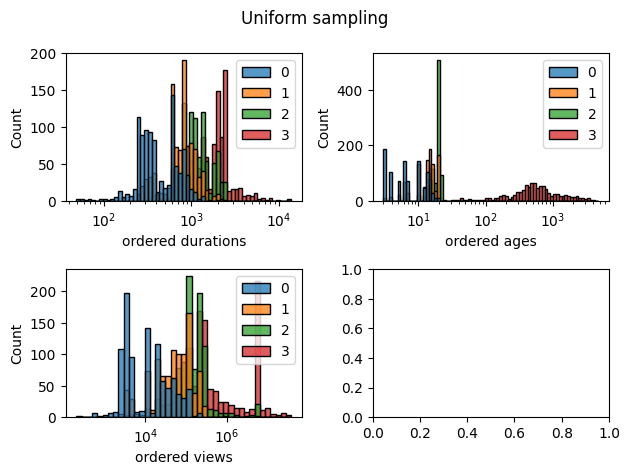

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

from utils import duration_in_secs

n_tests = 1000

#DPP
bundles_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

durations = df['duration'].apply(duration_in_secs)
ordered_duration = pd.DataFrame(
    data=[durations.loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
axs[0,0].set_xscale('log')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
axs[0,1].set_xscale('log')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.suptitle('DPP')
f.tight_layout()

#Uniform
bundles_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

ordered_duration = pd.DataFrame(
    data=[durations.loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
axs[0,0].set_xscale('log')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
axs[0,1].set_xscale('log')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.suptitle('Uniform sampling')
f.tight_layout()

### Criteria maximums

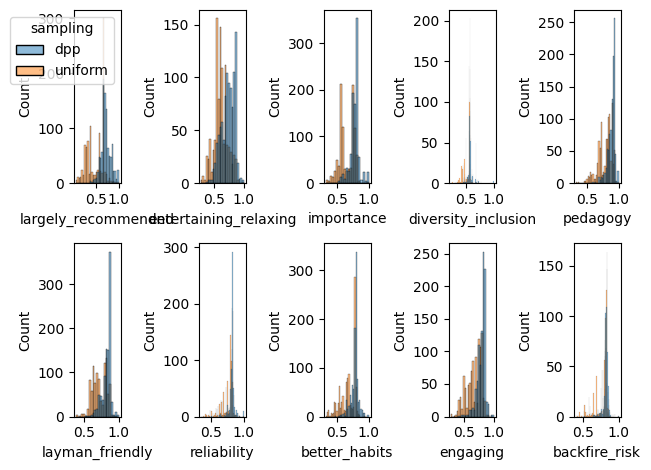

In [15]:
from utils import CRITERIA

n_tests = 1000

dpp_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

uniform_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 5)

maxs = df[CRITERIA].max()
mins = df[CRITERIA].min()

criteria_maximums = pd.DataFrame(
    columns = CRITERIA + ['sampling'],
    data = [
        list(
           (df.loc[df.index[bundle_indexes], CRITERIA].max()-mins)
                /(maxs-mins)
        )+['dpp']
        for bundle_indexes in dpp_indexes] + 
        [
        list(
           (df.loc[df.index[bundle_indexes], CRITERIA].max()-mins)
                /(maxs-mins)
        )+['uniform']
        for bundle_indexes in uniform_indexes]
)

for i in range(len(CRITERIA)):
    legend = False
    if i == 0:
        legend = True
    sns.histplot(data=criteria_maximums,
                x=CRITERIA[i], 
                hue='sampling',
                legend=legend,
                ax=axs[i % 2, i % 5]
    )
   

f.tight_layout()

### Determinants of bundle's features vectors

In [16]:
dpp.compute_L()

L (likelihood) kernel computed via:
- U diag(eig_L) U.T


<AxesSubplot:xlabel='determinant', ylabel='Count'>

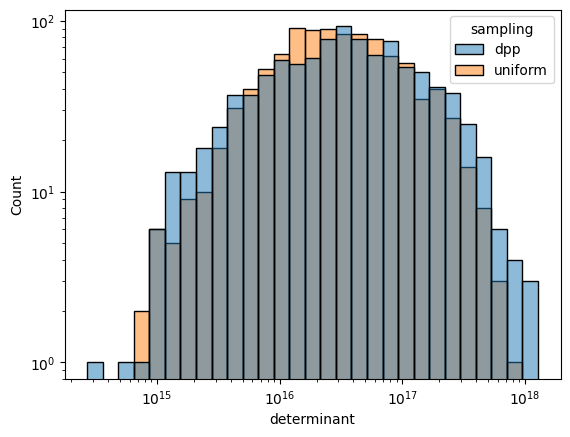

In [18]:
import seaborn as sns

n_tests = 1000

dpp_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

uniform_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

determinants = pd.DataFrame(
    columns = ['determinant', 'sampling'],
    data = [
        [
            np.abs(np.linalg.det(
                np.linalg.qr(dpp.L_gram_factor[:, indexes])[1]
            ))
        ] + ['dpp']
        for indexes in dpp_indexes
    ] +
    [
        [
            np.abs(np.linalg.det(
                np.linalg.qr(dpp.L_gram_factor[:, indexes])[1]
            ))
        ] + ['uniform']
        for indexes in uniform_indexes
    ]
)

sns.histplot(data=determinants, 
             x='determinant', 
             hue='sampling',
             log_scale=(True, True)
)
        